### Changelog
v1.2.0 - 12th March
- Q2 - Added clarification on merging approach of the dataframes.
- Updated requirements.txt to include Scipy.

v1.1.0 - 8th March
- Q1 - Added clarification that you may need to modify the file ingestion lines (i.e. file) to handle data cleansing.
- Q1 - Added clarification on NSW inclusions from crime_data.csv.
- Q1 - Added clarification on output of police_stations_df.
- Q2 - Added clarification on the output df.
- Updated requirements.txt to include more packages.

## COMP9321 26T1 Assignment 1 v1.2.0 (15 marks)

The NSW Government provides the community with public datasets and research about crime. 

This assignment uses the following data:

- `police_stations.json`: Information about all police stations in NSW and ACT, from the Bureau of Crime Statistics and Research (BOCSAR).
- `crime_data.csv`: Criminal incident information in NSW about offences, locations, and their frequency over time, from the Department of Customer Service.
- `postcodes.json`: A list of Australian postcodes, from the user "Elkfox" on Github.

### Assignment Instructions

Failure to follow these rules may result in penalties during marking. 

#### Environment Setup
- Use the provided `requirements.txt` to set up your virtual environment.
- Use only libraries available in the virtual environment (e.g., `pandas`, `matplotlib`).
- Use Python **3.13** only (i.e., the version installed on CSE).

#### Your Answers!
In this assignment you will need to provide three types of answers as explained in each question:
- Dataframe/Table as an output
    - Use the code cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#code-cells] where you see **# YOUR CODE GOES HERE**. If the last line of your code is the result dataframe, the notebook will automatically display the results. 
- Plots (visualisations)
   - Use the code cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#code-cells] where you see **# YOUR CODE GOES HERE**. For plots/images you need to have **plt.show()** as the last line of your code. 
- Written Responses
  - Use the markdown cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#markdown-cells] where you see **⛔ DELETE THIS TEXT AND REPLACE WITH YOUR ANSWER ⛔**. That placeholder text should be removed and replaced with your response.  Format your responses using Markdown syntax [https://www.markdownguide.org/basic-syntax/].

#### Coding Standards
- Do **not** use `for` or `while` loops over DataFrame rows or Series.
- Do **not** convert DataFrames to native Python types (`list`, `dict`) for processing.
- Plots/Dataframes answering the questions must be shown in the notebook output. For each question, there must be ONLY a single code cell with your code to address each task and its output should reflect your answer. You must make sure you include all outputs before submitting your notebook file. 
- Do **not** modify the provided code template structure; instead add your code where indicated by "YOUR CODE GOES HERE"
- You may write helper functions inside the code cell for the question where it is used.
- Pandas Operations- Your solutions should leverage efficient native Pandas operations (such as apply, drop, read_csv, etc.) rather than manual or iterative approaches. Additionally, ensure that DataFrames are properly indexed and sorted to enhance readability and facilitate easier data exploration.

#### Visualisation Standards
For questions 4 and 5, make sure you:
- Choose a suitable chart type for the data.
- Use appropriate scale and colour.
- Include title, axis labels, and legend with readable sizing.
- Ensure the visualisation is self-explanatory and informative.
- You may use sub-plots inside one window to fit multiple visualisations.
#### Submission
- You can use WebCMS to submit your notebook file which should be named **zid.ipynb** (e.g., z123456.ipynb). You only need to submit the notebook file. Your notebook must not exceed 5MB. 
- Make sure you **include all the outputs** in the notebook file (run all cells before submission), otherwise you will be penalised by 50% of the maximum marks for that question.
- Late submission is permitted with a 5% penalty per day, and you can submit no later than 5 days late.

## Run this prior to your question blocks.

In [1]:
# Make sure you copy the dataset files to the same directory as your notbook

import warnings
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# NOTE: If you need to import any other libraries, you can do so here,  
# provided they are available within the virtual environment.
# (see "Environment Setup" in the assignment instructions above)

# Set display options and ignore warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 5)
pd.set_option("display.max_columns", None)

---

# Question 1 (3 marks)

---

You need to clean both the **crime_data_df** and **police_stations_df**  dataframes by applying best data wrangling practices. This includes, but is not limited to, checking for missing values, removing unnecessary columns, and any obvious data quality issues. It is part of the assignment to explore the dataset and the assignment requirements (including all questions) and clean the dataset as much as you can. **Do not clean the dataset files directly**, but instead read the file in and apply the transformations in your code.

*v1.1.0 update - you may need to modify the ingestion line (i.e., look inside the optional parameters for read_csv such as on_bad_lines), to clean the dataset to allow it to be loaded, before you can apply further cleaning to it.*

Only include data for NSW - exclude all other states and territories. 

*v1.1.0 update - the crime_data.csv file only includes data from NSW. This can be relied upon to achieve this.*

**crime_data_df** is a wide dataset and you are also tasked to transform **crime_data_df**; the transformed dataframe must include the following columns.

- `suburb`
- `category`
- `sub_category`
- `date`
- `crime_count`

You should populate the fields with their equivalent values from the original **crime_data_df**.

*v1.1.0 update -the police_stations_df dataset should only include the following columns.*

- `police_station_name`
- `EPSG_3857_x`
- `EPSG_3857_y`

**Marking Criteria**
- [2.5 marks] The dataframes are fully cleaned and transformed using the most efficient pandas operations. 
- [0.5 marks] The written responses for how any data quality issues have been identified and rectified are sound and complete.


## Crime dataset

In [3]:
# YOUR CODE GOES HERE - Clean the crime data dataframe, name it (crime_data_df) and show the dataframe as output of your cell
crime_data_df = pd.read_csv(
    "crime_data.csv", on_bad_lines='skip', index_col=False
)
postcodes = pd.read_json('postcodes.json')
postcodes1 = postcodes[postcodes["state_code"] == "NSW"]["place_name"]
crime_data_df = crime_data_df[
    crime_data_df["Suburb"].isin(postcodes1)
]
crime_data_df = crime_data_df.drop_duplicates()                                                                                                                     
crime_data_df['Subcategory'] = crime_data_df['Subcategory'].str.replace(r'\*','',regex=True)  
crime_data_df['Subcategory'] = crime_data_df['Subcategory'].str.strip()                              
# crime_data_df['Jan 1995'] = pd.to_numeric(crime_data_df['Jan 1995'], errors='coerce')
crime_data_df.iloc[:,3:] = crime_data_df.iloc[:,3:].apply(pd.to_numeric, errors="coerce")  
crime_data_df = crime_data_df.dropna(subset=["Suburb","Offence category","Subcategory"])
crime_data_df["Jan 1995"] = crime_data_df["Jan 1995"].fillna(0)
crime_data_df['Jan 1995'] = crime_data_df['Jan 1995'].astype(int)
crime_data_df = crime_data_df[
    (crime_data_df.iloc[:, 3:] != 0).any(axis=1)
]


date_cols = crime_data_df.columns[3:]

crime_data_df = crime_data_df.melt(
    id_vars=["Suburb", "Offence category", "Subcategory"],
    value_vars=date_cols,
    var_name="date",
    value_name="crime_count"
)


crime_data_df = crime_data_df.rename(columns={"Suburb":"suburb"})
crime_data_df = crime_data_df.rename(columns={"Offence category":"category"})
crime_data_df = crime_data_df.rename(columns={"Subcategory":"sub_category"})
crime_data_df["date"] = pd.to_datetime(crime_data_df["date"])
# crime_data_df.isna().sum() #Checking for missing values 
# Do not change the following line of code (this will print the dataframe as an output after running the cell)
crime_data_df

,suburb,category,sub_category,date,crime_count
0,Aarons Pass,Assault,Domestic violence related assault,1995-01-01,0
1,Aarons Pass,"Intimidation, stalking and harassment","Intimidation, stalking and harassment",1995-01-01,0
...,...,...,...,...,...
49751390,Zetland,Transport regulatory offences,Transport regulatory offences,2025-09-01,0
49751391,Zetland,Other offences,Other offences,2025-09-01,0


In [4]:
# Do not change the following line of code (this will print the dataframe as an output after running the cell)
crime_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49751392 entries, 0 to 49751391
Data columns (total 5 columns):
 #   Column        Dtype         
---  ------        -----         
 0   suburb        str           
 1   category      str           
 2   sub_category  str           
 3   date          datetime64[us]
 4   crime_count   int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 1.9 GB


### ✍️ Written Response – Cleaning `crime_data_df`

**Instructions:**  
Provide concise bullet points under each heading below.  
Focus on *what issues were identified and why your cleaning decisions were appropriate*.  
Do not describe specific lines of code.

**Data Quality Issues Identified**
- ⛔
- Column Asterisk Problem    
- Column Misalignment
- Duplicate Records
- Non-Numeric Values
- Load CSV Error 
- Remove records with no reported crimes
- Only include data for NSW
- ⛔

**Cleaning Steps Applied**
- ⛔
- Using regular expressionto match asterisk.
- Changing index column to false
- Using function to deduplicate 
- Convert specific columns to integers
- Skip bad rows
- Check whether all monthly crime values are zero
- Using postcodes to check suburb⛔

**Justification**
- ⛔ 
- Reduce category mistakes
- Prevent incorrect column parsing
- improves the accuracy of the dataset
- Facilitate consistent aggregation of crime data.
- Prevent incorrect rows causing error.
- To facilitate computation and prevent excessive data volume.
- Reduce computational cost
⛔

## Police station dataset

In [5]:
# YOUR CODE GOES HERE - Clean the police stations dataframe, name it (police_stations_df) and show the dataframe as output of your cell
police_stations_df = pd.read_json('police_stations.json')
data_key = 'features'
if data_key not in police_stations_df:
    raise KeyError(f"{data_key} not found in JSON")
police_stations_df = pd.json_normalize(police_stations_df['features'])
police_stations_df = police_stations_df.rename(columns={
    "attributes.generalname":"police_station_name",
    "geometry.x":"EPSG_3857_x",
    "geometry.y":"EPSG_3857_y"
})
police_stations_df.isna().sum()
police_stations_df = police_stations_df.drop_duplicates()
police_stations_df['police_station_name'] = police_stations_df['police_station_name'].str.strip()
police_stations_df['police_station_name'] = police_stations_df['police_station_name'].str.title()
police_stations_df.dtypes         # Checked for type issues

# Do not change the following line of code
police_stations_df

,police_station_name,EPSG_3857_x,EPSG_3857_y
0,Ariah Park Police Station,1.638830e+07,-4.075472e+06
1,Koorawatha Police Station,1.653723e+07,-4.033926e+06
...,...,...,...
425,Balranald Police Station,1.598160e+07,-4.115261e+06
426,Hay Police Station,1.612377e+07,-4.097334e+06


In [6]:
# Do not change the following line of code
police_stations_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   police_station_name  427 non-null    str    
 1   EPSG_3857_x          427 non-null    float64
 2   EPSG_3857_y          427 non-null    float64
dtypes: float64(2), str(1)
memory usage: 10.1 KB


### ✍️ Written Response – Cleaning `police_stations_df`

**Instructions:**  
Provide concise bullet points under each heading below.  
Focus on *what issues were identified and why your cleaning decisions were appropriate*.  
Do not describe specific lines of code.

**Data Quality Issues Identified**
- ⛔ 
- Checked for missing values.
- Checked for data duplicate.
- Checked for data types issues ⛔

**Cleaning Steps Applied**
- ⛔ 
- Using 'isna' check missing values
- Remove duplicate values
- Using 'dtypes' to check column types ⛔

**Justification**
- ⛔ 
- Improves data accurancy
- Removing duplicate data to prevent information
- Ensuring data type consistent⛔


## Postcodes dataset (no action required)

In [7]:
# Do not change the following lines of code
postcodes_df = pd.read_json('postcodes.json')
postcodes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16875 entries, 0 to 16874
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   postcode    16875 non-null  int64  
 1   place_name  16875 non-null  str    
 2   state_name  16875 non-null  str    
 3   state_code  16875 non-null  str    
 4   latitude    16875 non-null  float64
 5   longitude   16875 non-null  float64
 6   accuracy    16871 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 923.0 KB


---

# Question 2 (2 marks)

---

Merge the cleaned crime data and police stations dataframes into a single dataframe. Join the result dataframe with the postcodes dataset - the result dataframe should add four extra columns named `police_station_name`, and their WGS84 coordinates as `latitude`, `longitude` to the suburbs nearest police station, and `postcode`. 

All postcodes should be valid 4 digit values, or replaced as 9999 if not available.

*v1.1.0 update - the final output of this question, from left to right, would be:*
- The five columns in crime_data_df
- The three columns in police_stations_df
- The requested four new columns 

*Each row should be matched by using the available postcodes_df to find the appropriate police station for each suburb in the crime data.*

*v1.2.0 update - although the description above recommends a specific ordered merge approach, you may apply any operations in any order you wish to achieve the final outcome requested.*

**Marking Criteria**
- [1 mark]  The dataframes have been joined and cleaned successfully.
- [1 mark]  The nearest police stations are correct.

In [8]:
# YOUR CODE GOES HERE - name your output merged_df

postcodes_df = postcodes_df[postcodes_df["state_code"] == "NSW"]
postcodes_df.rename(columns={'place_name': 'suburb'}, inplace=True)
postcodes_df = postcodes_df.drop_duplicates(subset="suburb")

suburb_unique = crime_data_df[["suburb"]].drop_duplicates()
suburb_unique = suburb_unique.merge(postcodes_df[["suburb", "latitude", "longitude", "postcode"]], on="suburb", how="left")
# join_df = crime_data_df.merge(postcodes_df, on="suburb", how="left")


trans = gpd.GeoDataFrame(police_stations_df, geometry=gpd.points_from_xy(police_stations_df['EPSG_3857_x'], police_stations_df['EPSG_3857_y']), crs="EPSG:3857")
trans = trans.to_crs("EPSG:4326")
police_stations_df["longitude"] = trans.geometry.x
police_stations_df["latitude"] = trans.geometry.y
police2 = police_stations_df[["police_station_name", "latitude", "longitude"]]

suburb_loc = gpd.GeoDataFrame(suburb_unique, geometry=gpd.points_from_xy(suburb_unique["longitude"], suburb_unique["latitude"]), crs="EPSG:4326")
# suburb_loc = gpd.GeoDataFrame(join_df, geometry=gpd.points_from_xy(join_df["longitude"], join_df["latitude"]), crs="EPSG:4326")
polic_loc = gpd.GeoDataFrame(police2, geometry=gpd.points_from_xy(police_stations_df["longitude"], police_stations_df["latitude"]), crs="EPSG:4326")

nearest_loc = gpd.sjoin_nearest(suburb_loc, polic_loc[["police_station_name","geometry"]],how="left")
nearest_loc = nearest_loc[["suburb","police_station_name","postcode","latitude","longitude"]]

nearest_loc = nearest_loc.drop_duplicates(subset="suburb")
merged_df = crime_data_df.merge(nearest_loc, on="suburb", how="left")


nearest_loc["postcode"] = nearest_loc["postcode"].astype(str)
nearest_loc["postcode"] = pd.to_numeric(nearest_loc["postcode"].str.extract(r'^(\d{4})', expand=False), errors='coerce')
nearest_loc["postcode"] = nearest_loc["postcode"].fillna(9999).astype(int)


merged_df = merged_df[
    [
        "suburb",
        "category",
        "sub_category",
        "date",
        "crime_count",
        "police_station_name",
        "latitude",
        "longitude",
        "postcode"
    ]
]

# Do not change the following line of code
merged_df

,suburb,category,sub_category,date,crime_count,police_station_name,latitude,longitude,postcode
0,Aarons Pass,Assault,Domestic violence related assault,1995-01-01,0,Mudgee Police Station,-32.6278,149.6520,2850
1,Aarons Pass,"Intimidation, stalking and harassment","Intimidation, stalking and harassment",1995-01-01,0,Mudgee Police Station,-32.6278,149.6520,2850
...,...,...,...,...,...,...,...,...,...
49751390,Zetland,Transport regulatory offences,Transport regulatory offences,2025-09-01,0,Redfern Police Station,-33.9075,151.2086,2017
49751391,Zetland,Other offences,Other offences,2025-09-01,0,Redfern Police Station,-33.9075,151.2086,2017


---

# Question 3 (4 marks)

---

NSW Police want to better understand how to allocate their resources in the upcoming financial year (1 July 2026 to 30 June 2027). They need your help to digest crime trends across NSW into actionable outcomes. This should be aimed at senior police executives, who are time-poor and not trained at reading large and complex datasets.

You are tasked with building a summary table that helps NSW Police understand the police stations with the highest number of incidents for each crime, and their offence rates. Consider how this has changed over time, and also the variance between different parts of NSW. Ensure the information is easily digestible - do not overwhelm the reader with large responses. At the same time, do not cut out details which can bias your conclusions.

**Marking Criteria**
- [2 marks] A suitable dataframe as an output to fullfil the requirement.
- [2 marks] An accurate, detailed, and relevant analysis of your results — remark on what conclusions you can draw from the output dataframe.

In [10]:
# YOUR CODE GOES HERE - your pivot table should be named summary_df
merged_df["year"] = merged_df["date"].dt.year
summary_df = merged_df.groupby(['year', "police_station_name","category"])["crime_count"].sum()
summary_df =summary_df.reset_index()

offence_rate = (merged_df.groupby(['year', 'police_station_name', "category"])["crime_count"].mean().reset_index().rename(columns={"crime_count": "offence_rate"}))

summary_df = summary_df.merge(offence_rate, on=['year', "police_station_name", "category"])
summary_df = (summary_df[summary_df["crime_count"] > 0].sort_values(["category", "crime_count"], ascending=[True, False])
)

# Do not change the following lines of code
pd.set_option('display.max_rows', 50)
summary_df

,year,police_station_name,category,crime_count,offence_rate
57437,2002,Day Street Police Station,Abduction and kidnapping,25,0.694444
52117,2001,Mount Druitt Police Station,Abduction and kidnapping,20,0.092593
103232,2008,Blacktown Police Station,Abduction and kidnapping,20,0.111111
9246,1996,Cabramatta Police Station,Abduction and kidnapping,17,0.202381
25002,1998,Cabramatta Police Station,Abduction and kidnapping,17,0.202381
...,...,...,...,...,...
241874,2025,Parramatta Police Station,Transport regulatory offences,1,0.027778
242084,2025,Queanbeyan Police Station,Transport regulatory offences,1,0.013889
242104,2025,Quirindi Police Station,Transport regulatory offences,1,0.111111
242772,2025,Tamworth Police Station,Transport regulatory offences,1,0.009259


### ✍️ Written Response – Question 3

**Instructions:**  
Provide a concise executive-level analysis supported by your summary table (150–300 words recommended).  
Use bullet points where appropriate.  
Focus on insights, not code description.

⛔
- This table shows the police station with the highest number of incidents each year and the corresponding average monthly offence rate, follow by the year. 
- From the summary table, the offence type with the highest number of incidents is Abduction and kidnapping. The corresponding police stations, such as Day Street, Mount Druitt, and Blacktown Police Station, are mainly located in major metropolitan areas, and their offence rates are also relatively high.

- In contrast, Transport regulatory offences have the lowest number of recorded incidents, with only one case recorded in recent years. The associated police stations, such as Tamworth, Tweed Heads, and Quirindi, are primarily regional police stations. This suggests that there may be geographical differences in crime levels across different suburbs in NSW.

- The high frequency of Abduction and kidnapping incidents may indicate that these crimes are more common in densely populated urban areas, suggesting that more police resources may need to be allocated to major metropolitan regions. By comparison, areas with fewer recorded crimes only show data from recent years, which suggests that crime levels in these regions remain relatively stable.

- Overall, the summary table clearly shows differences in crime levels across various regions of New South Wales, providing data-driven support for more targeted and efficient allocation of police resources.
⛔

---

# Question 4 (3 marks)

---

Provide actionable recommendations for the general public supported by appropriate visualisation(s) for how crime changes across Sydney during a typical calendar year. Feel free to create subplots within a single view to support your recommendations.

**Marking Criteria:**
- [2 marks] The visualisation, and your accompanying explanation, has depth and relevance to the community about crime changes during a typical calendar year in Sydney.
- [1 mark] The visualisation maintains a professional standard of visual quality, clarity, formatting, and correctness.



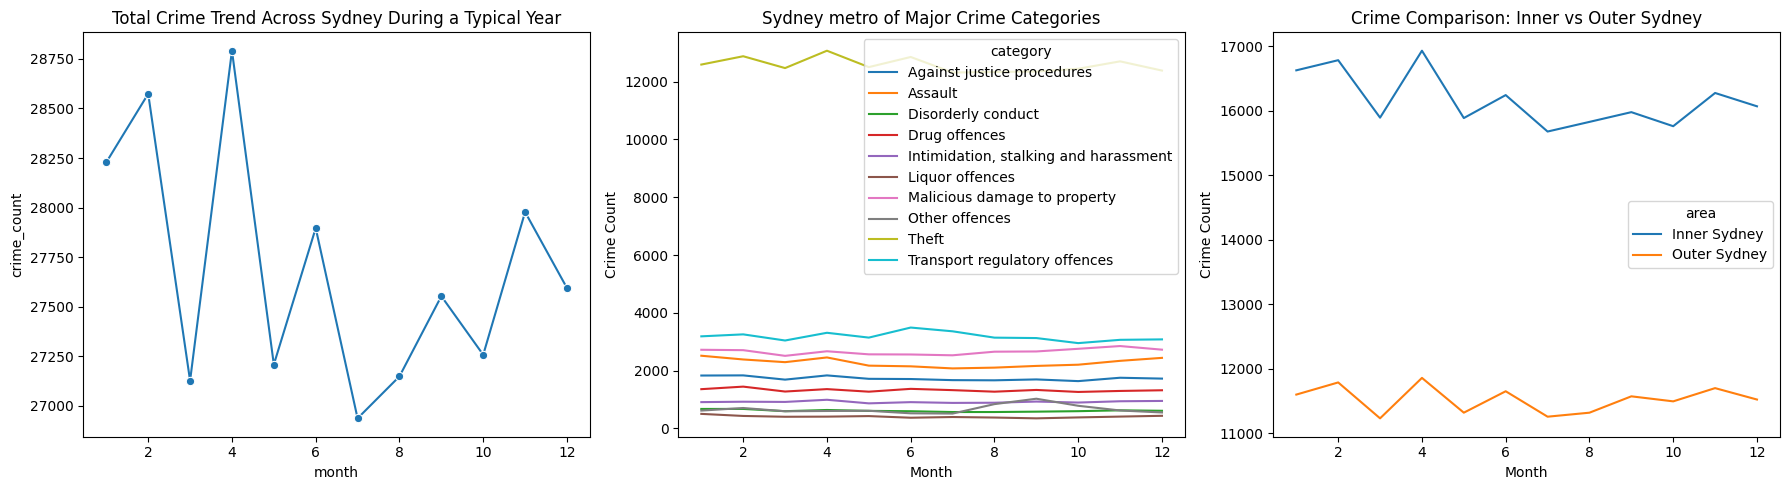

In [9]:
# YOUR CODE GOES HERE - your visualisation must be shown as an output at the end of this cell
fig, axes = plt.subplots(1,3, figsize=(18, 5))
greater_syd_df = merged_df[
    ((merged_df["postcode"] >= 1000) & (merged_df["postcode"] <= 2249)) |
    ((merged_df["postcode"] >= 2760) & (merged_df["postcode"] <= 2770))
]

greater_syd_df["year"] = greater_syd_df["date"].dt.year
greater_syd_df["month"] = greater_syd_df["date"].dt.month
tot_month = greater_syd_df.groupby(['year', 'month'])['crime_count'].sum().reset_index()
monthly_avg = (
    tot_month
    .groupby("month")["crime_count"]
    .mean()
    .reset_index()
)

top_crime = (greater_syd_df.groupby("category")["crime_count"].sum().nlargest(10).index)
crime_c = (greater_syd_df[greater_syd_df["category"].isin(top_crime)].groupby(['year', "month","category"])["crime_count"].sum().reset_index())
crime_c = (crime_c.groupby(["month","category"])["crime_count"].mean().reset_index()
)

greater_syd_df["area"] = "Outer Sydney"
greater_syd_df.loc[greater_syd_df["postcode"] < 2100, "area"] = "Inner Sydney"

outer_month = (greater_syd_df.groupby(['year', "month","area"])["crime_count"].sum().reset_index())
outer_month = (outer_month.groupby(["month","area"])["crime_count"].mean().reset_index())


sns.lineplot(data= monthly_avg,x="month",y="crime_count",marker="o",ax=axes[0])
axes[0].set_title("Total Crime Trend Across Sydney During a Typical Year")

# 2 Top crime types
sns.lineplot(data=crime_c, x="month", y="crime_count", hue="category", ax=axes[1])
axes[1].set_title("Sydney metro of Major Crime Categories")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Crime Count")

# 3 Inner comapres Outer Sydney
sns.lineplot(data=outer_month, x="month", y="crime_count", hue="area", ax=axes[2])
axes[2].set_title("Crime Comparison: Inner vs Outer Sydney")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Crime Count")

plt.tight_layout() 
#                      (do not store the image - it should be shown after this cell once you run this cell)
plt.show()

### ✍️ Written Response – Question 4

**Instructions:**  
Provide clear, public-facing recommendations supported by your visualisation (150–300 words recommended).

⛔ 
- The three figures illustrate the overall crime trends in Sydney during a typical year, the trends of major crime categories, and a comparison of crime counts between Inner and Outer Sydney.

- The Sydney metropolitan area was defined based on the Sydney metro postcode ranges provided in the following source:
http://www.impactlists.com.au/ImpactLists/media/list-tools/Useful-Postcode-Ranges.pdf

- Within this range, areas with postcodes below 2100 were classified as Inner Sydney, while those above were classified as Outer Sydney.

- From Figure 1, the total number of crimes in a typical year generally shows a decreasing trend from the beginning to the end of the year. Crime incidents peak in April, reaching approximately 28,750 cases, while the lowest number occurs in July, with fewer than 27,000 incidents.

- Figure 2 shows that Theft has the highest number of incidents among all crime categories, significantly exceeding other types of crime. This indicates that additional attention should be given to theft-related offences. In contrast, Liquor offences have the lowest number of incidents throughout the year.

- Figure 3 indicates that the total number of crimes in Inner Sydney is significantly higher than in Outer Sydney throughout the year. This suggests that more police resources and management efforts may be required in inner-city areas.

- Overall, during a typical year in Sydney, crime levels in Inner Sydney are higher than those in Outer Sydney, and theft-related offences account for the largest proportion of crimes. Therefore, greater attention should be given to crime prevention in inner-city areas, such as increasing police patrols and installing additional surveillance cameras. Furthermore, as crime levels appear relatively higher before June, it may be beneficial for police stations to strengthen patrol activities during the first half of the year.
⛔

---

# Question 5 (3 marks)

---

NSW Police would like to investigate if there are offences in recent years that could present an increased risk to the community in the coming years. As a data analyst, your task is to verify or challenge the following claim:

> Major crimes have generally decreased throughout NSW in recent years. However, some crimes in specific areas have observed a significant increase.

Feel free to create subplots within a single view to support your recommendations.

**Marking Criteria:**
- [2 marks] The visualisation, and your accompanying explanation, effectively identifies trends and patterns that thorough verify or challenge the claim.
- [1 mark] The visualisation maintains a professional standard of visual quality, clarity, formatting, and correctness.



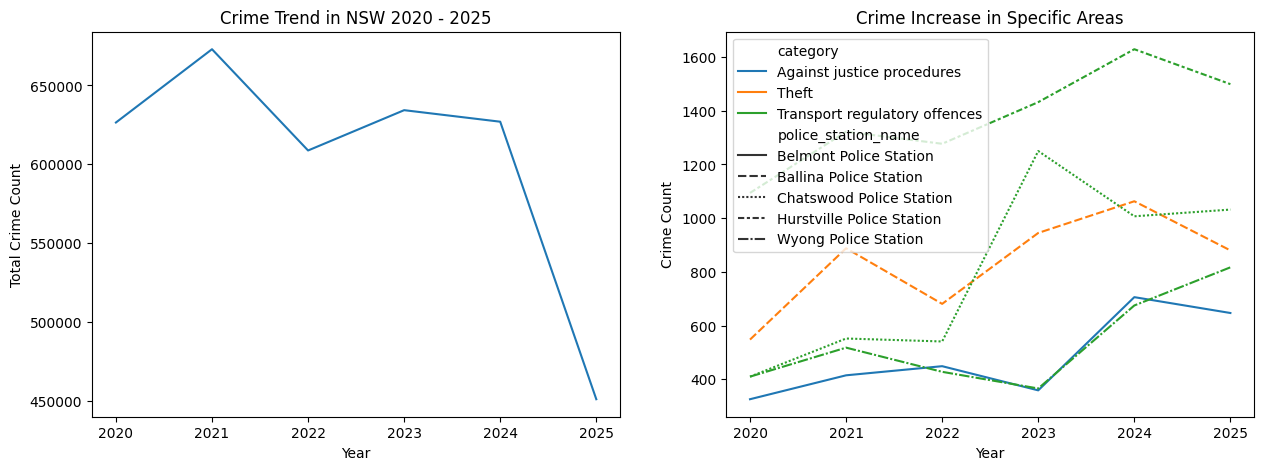

In [11]:
# YOUR CODE GOES HERE - your visualisation must be shown as an output at the end of this cell
merged_df['year'] = merged_df['date'].dt.year
rec_df = merged_df[merged_df['year'] >= 2020]

fig, axes = plt.subplots(1,2, figsize=(15,5))
yearly_total = rec_df.groupby("year")["crime_count"].sum().reset_index()

sns.lineplot(data=yearly_total, x="year", y="crime_count", ax=axes[0])
# Recent year chose from 2020 to 2025
axes[0].set_title("Crime Trend in NSW 2020 - 2025")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Crime Count") 

crime_area = (rec_df.groupby(["year", "category", 'police_station_name'])["crime_count"].sum().reset_index())

# Check increase areas
trend_start = crime_area[crime_area['year'] == 2020]
trend_end = crime_area[crime_area['year'] == 2025]
tot_trend = trend_start.merge(trend_end, on=["category","police_station_name"],suffixes=("_st","_end"))

# Check specific decrease areas
tot_trend['increase_num'] = tot_trend['crime_count_end'] - tot_trend["crime_count_st"]
tot_trend = tot_trend.sort_values("increase_num", ascending=False)

spe_area = tot_trend.head(5)        

plot_df = crime_area.merge(spe_area[["category","police_station_name"]])

sns.lineplot(data=plot_df, x="year", y="crime_count", hue="category", style="police_station_name", ax=axes[1])

axes[1].set_title("Crime Increase in Specific Areas")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Crime Count")

#                      (do not store the image - it should be shown after this cell once you run this cell)
plt.show()

### ✍️ Written Response – Question 5

**Instructions:**  
Evaluate the claim using evidence from your analysis (150–300 words recommended).

⛔ 
- The two figures illustrate the overall crime trend in NSW and the crime types that have increased in specific areas.

- Figure 1 shows the overall crime trend in NSW based on recent data from 2020 to 2025. The total number of crimes demonstrates a decreasing trend, declining from approximately 680,000 incidents to around 450,000.

- Figure 2 indicates that some crime types within certain police station jurisdictions still show an increasing trend. Different colours and line styles in the chart represent different police station areas and their corresponding crime categories. For example, Transport regulatory offences within the Hurstville Police Station area experienced the most significant growth, increasing from approximately 1,100 incidents to about 1,500 incidents. Some crimes show slower increases but still maintain an overall upward trend, such as Against justice procedures in the Belmont Police Station area.

- Overall, crime levels in NSW have generally decreased in recent years. However, certain offences such as transport regulatory offences and theft have shown noticeable increases in some police station areas, indicating potential emerging risks for local communities.
⛔

---

*End of Assignment*